In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../UCI-Heart-Disease-Dataset-master/data/heart-disease-UCI.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
# ببینیم چند تا سطر و ستون داریم
print("تعداد سطر و ستون:", df.shape)

# ببینیم ستون‌ها چی هستن
print("\nاسم ستون‌ها:")
print(df.columns.tolist())

# ببینیم چندتا مقدار NaN داریم
print("\nتعداد NaN در هر ستون:")
print(df.isnull().sum())

تعداد سطر و ستون: (303, 14)

اسم ستون‌ها:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

تعداد NaN در هر ستون:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


آمار توصیفی داده‌ها:
          age     sex      cp  trestbps    chol     fbs  restecg  thalach  \
count  303.00  303.00  303.00    303.00  303.00  303.00   303.00   303.00   
mean    54.37    0.68    0.97    131.62  246.26    0.15     0.53   149.65   
std      9.08    0.47    1.03     17.54   51.83    0.36     0.53    22.91   
min     29.00    0.00    0.00     94.00  126.00    0.00     0.00    71.00   
25%     47.50    0.00    0.00    120.00  211.00    0.00     0.00   133.50   
50%     55.00    1.00    1.00    130.00  240.00    0.00     1.00   153.00   
75%     61.00    1.00    2.00    140.00  274.50    0.00     1.00   166.00   
max     77.00    1.00    3.00    200.00  564.00    1.00     2.00   202.00   

        exang  oldpeak   slope      ca    thal  target  
count  303.00   303.00  303.00  303.00  303.00  303.00  
mean     0.33     1.04    1.40    0.73    2.31    0.54  
std      0.47     1.16    0.62    1.02    0.61    0.50  
min      0.00     0.00    0.00    0.00    0.00    0.00  


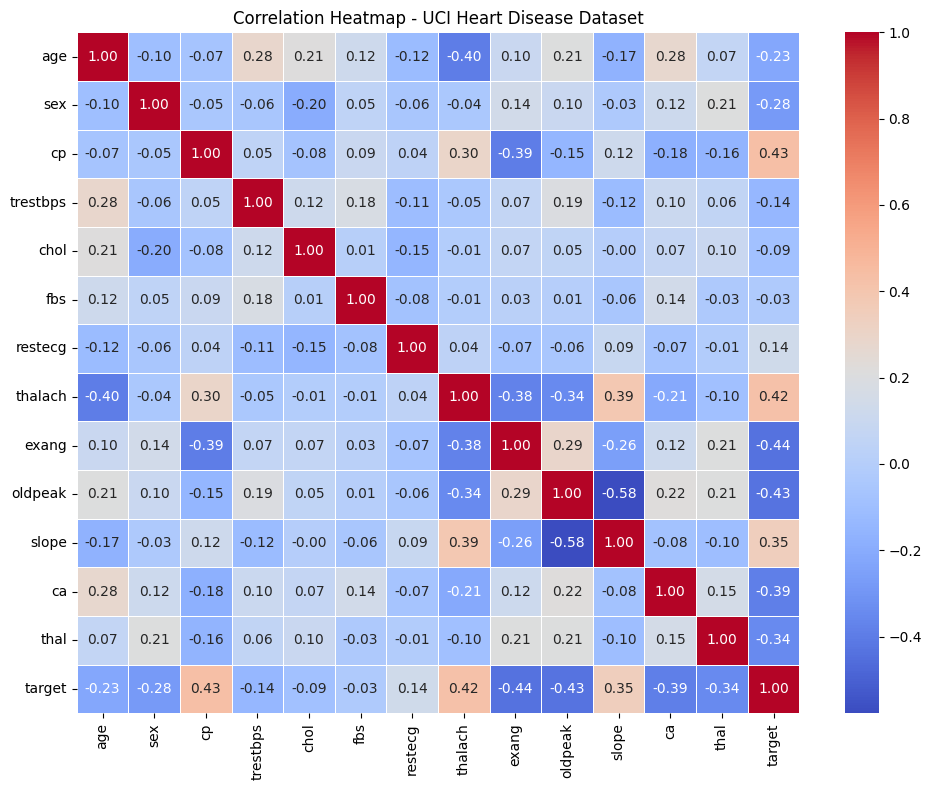

In [8]:
import seaborn as sns

print("آمار توصیفی داده‌ها:")
print(df.describe().round(2))

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - UCI Heart Disease Dataset')
plt.tight_layout()
plt.savefig(r'\Users\Farzad\Desktop\aks', dpi=300)
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("تعداد داده‌های آموزش:", X_train.shape[0])
print("تعداد داده‌های تست:", X_test.shape[0])
print("\nتوزیع کلاس‌ها در y_train:")
print(y_train.value_counts())
print("\nتوزیع کلاس‌ها در y_test:")
print(y_test.value_counts())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nمیانگین داده‌های آموزش بعد از نرمال‌سازی (باید نزدیک صفر باشد):")
print(X_train_scaled.mean(axis=0).round(4))
print("\nانحراف معیار داده‌های آموزش بعد از نرمال‌سازی (باید نزدیک یک باشد):")
print(X_train_scaled.std(axis=0).round(4))
print(X_test_scaled.std(axis=0).round(4))
print(X_test_scaled.mean(axis=0).round(4))


تعداد داده‌های آموزش: 242
تعداد داده‌های تست: 61

توزیع کلاس‌ها در y_train:
target
1    132
0    110
Name: count, dtype: int64

توزیع کلاس‌ها در y_test:
target
1    33
0    28
Name: count, dtype: int64

میانگین داده‌های آموزش بعد از نرمال‌سازی (باید نزدیک صفر باشد):
[ 0.  0.  0.  0. -0. -0.  0. -0.  0.  0.  0.  0.  0.]

انحراف معیار داده‌های آموزش بعد از نرمال‌سازی (باید نزدیک یک باشد):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[0.9621 0.9943 1.107  0.8688 1.3601 1.1064 0.9401 1.193  0.9473 0.7903
 0.9654 0.8994 1.0439]
[ 0.0419  0.0144  0.1226 -0.0229  0.1435  0.1146 -0.1631 -0.1081 -0.1271
 -0.1333 -0.1114 -0.0689 -0.2082]


ابعاد داده آموزش قبل از KPCA: (242, 13)
ابعاد داده آموزش بعد از KPCA: (242, 8)
ابعاد داده تست بعد از KPCA: (61, 8)

نسبت واریانس توضیح داده شده توسط هر مؤلفه KPCA:
  مؤلفه 1: 0.2624 (26.24%)
  مؤلفه 2: 0.1569 (15.69%)
  مؤلفه 3: 0.1190 (11.90%)
  مؤلفه 4: 0.1160 (11.60%)
  مؤلفه 5: 0.1013 (10.13%)
  مؤلفه 6: 0.0911 (9.11%)
  مؤلفه 7: 0.0794 (7.94%)
  مؤلفه 8: 0.0739 (7.39%)

مجموع واریانس توضیح داده شده: 1.0000


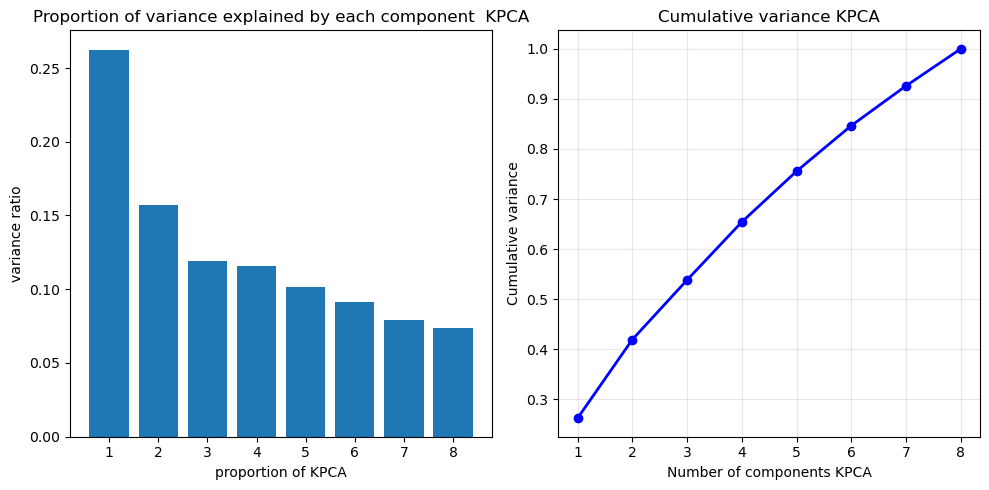

In [17]:
from sklearn.decomposition import KernelPCA

kpca = KernelPCA(n_components=8, kernel='rbf', gamma=0.1, random_state=42)

X_train_kpca = kpca.fit_transform(X_train_scaled)
X_test_kpca = kpca.transform(X_test_scaled)

print("ابعاد داده آموزش قبل از KPCA:", X_train_scaled.shape)
print("ابعاد داده آموزش بعد از KPCA:", X_train_kpca.shape)
print("ابعاد داده تست بعد از KPCA:", X_test_kpca.shape)

explained_variance = np.var(X_train_kpca, axis=0)
explained_variance_ratio = explained_variance / np.sum(explained_variance)

print("\nنسبت واریانس توضیح داده شده توسط هر مؤلفه KPCA:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"  مؤلفه {i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

print(f"\nمجموع واریانس توضیح داده شده: {np.sum(explained_variance_ratio):.4f}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, 9), explained_variance_ratio)
plt.xlabel('proportion of KPCA')
plt.ylabel('variance ratio')
plt.title('Proportion of variance explained by each component  KPCA')
plt.xticks(range(1, 9))

plt.subplot(1, 2, 2)
plt.plot(range(1, 9), np.cumsum(explained_variance_ratio), 'bo-', linewidth=2)
plt.xlabel('Number of components KPCA')
plt.ylabel('Cumulative variance')
plt.title('Cumulative variance KPCA')
plt.xticks(range(1, 9))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kpca_variance.png', dpi=300)
plt.show()

In [19]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
"AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42)}

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

results = {}
for name, model in models.items():
    model.fit(X_train_kpca, y_train)
    y_pred = model.predict(X_test_kpca)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    spec = specificity_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    results[name] = [acc, prec, rec, spec, f1]
    
    print(f"\n{'='*50}")
    print(f"مدل: {name}")
    print(f"{'='*50}")
    print(f"Accuracy:    {acc:.4f}")
    print(f"Precision:   {prec:.4f}")
    print(f"Sensitivity: {rec:.4f}")
    print(f"Specificity: {spec:.4f}")
    print(f"F-measure:   {f1:.4f}")

# ۴. ساخت جدول نتایج (مشابه جدول ۳ مقاله)
print(f"\n{'='*70}")
print("جدول خلاصه نتایج - مدل‌های پایه")
print(f"{'='*70}")
print(f"{'مدل':<20} {'Accuracy':<12} {'Precision':<12} {'Sensitivity':<12} {'Specificity':<12} {'F-measure':<12}")
print("-" * 70)
for name, metrics in results.items():
    print(f"{name:<20} {metrics[0]:<12.4f} {metrics[1]:<12.4f} {metrics[2]:<12.4f} {metrics[3]:<12.4f} {metrics[4]:<12.4f}")


مدل: Naive Bayes
Accuracy:    0.7705
Precision:   0.7879
Sensitivity: 0.7879
Specificity: 0.7500
F-measure:   0.7879

مدل: Logistic Regression
Accuracy:    0.7869
Precision:   0.7500
Sensitivity: 0.9091
Specificity: 0.6429
F-measure:   0.8219

مدل: SVM
Accuracy:    0.8033
Precision:   0.7838
Sensitivity: 0.8788
Specificity: 0.7143
F-measure:   0.8286

مدل: Random Forest
Accuracy:    0.7705
Precision:   0.7436
Sensitivity: 0.8788
Specificity: 0.6429
F-measure:   0.8056

مدل: AdaBoost
Accuracy:    0.8197
Precision:   0.7895
Sensitivity: 0.9091
Specificity: 0.7143
F-measure:   0.8451

جدول خلاصه نتایج - مدل‌های پایه
مدل                  Accuracy     Precision    Sensitivity  Specificity  F-measure   
----------------------------------------------------------------------
Naive Bayes          0.7705       0.7879       0.7879       0.7500       0.7879      
Logistic Regression  0.7869       0.7500       0.9091       0.6429       0.8219      
SVM                  0.8033       0.7838       0.

In [20]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeClassifier

class IterativeImprovedAdaBoost(BaseEstimator, ClassifierMixin):
    
    def __init__(self, n_estimators=50, learning_rate=1.0):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.alphas = []
        self.models = []
        
    def fit(self, X, y):
        n_samples = X.shape[0]
        
        w = np.ones(n_samples) / n_samples
        
        y_mod = np.where(y == 0, -1, 1)
        
        for m in range(self.n_estimators):
            model = DecisionTreeClassifier(max_depth=1, random_state=42+m)
            model.fit(X, y_mod, sample_weight=w)
            predictions = model.predict(X)
            
            err = np.sum(w * (predictions != y_mod)) / np.sum(w)
            
            err = np.clip(err, 1e-10, 1 - 1e-10)
            
            alpha = 0.5 * np.log((1 - err) / err)
            
            w *= np.exp(-alpha * y_mod * predictions)
            w /= np.sum(w) 
            
            self.alphas.append(alpha)
            self.models.append(model)
            
        return self
    
    def predict(self, X):
        final_pred = np.zeros(X.shape[0])
        for alpha, model in zip(self.alphas, self.models):
            final_pred += alpha * model.predict(X)
        
        return np.where(np.sign(final_pred) == -1, 0, 1)

In [21]:
print("آموزش SF-IIAdaboost...")
sf_model = IterativeImprovedAdaBoost(n_estimators=50)
sf_model.fit(X_train_kpca, y_train)

y_pred_sf = sf_model.predict(X_test_kpca)

acc_sf = accuracy_score(y_test, y_pred_sf)
prec_sf = precision_score(y_test, y_pred_sf, zero_division=0)
rec_sf = recall_score(y_test, y_pred_sf)
spec_sf = specificity_score(y_test, y_pred_sf)
f1_sf = f1_score(y_test, y_pred_sf, zero_division=0)

print(f"\n{'='*50}")
print("مدل پیشنهادی: SF-IIAdaboost")
print(f"{'='*50}")
print(f"Accuracy:    {acc_sf:.4f}")
print(f"Precision:   {prec_sf:.4f}")
print(f"Sensitivity: {rec_sf:.4f}")
print(f"Specificity: {spec_sf:.4f}")
print(f"F-measure:   {f1_sf:.4f}")

results["SF-IIAdaboost [Proposed]"] = [acc_sf, prec_sf, rec_sf, spec_sf, f1_sf]

print(f"\n{'='*80}")
print("جدول نهایی مقایسه همه مدل‌ها")
print(f"{'='*80}")
print(f"{'مدل':<25} {'Accuracy':<12} {'Precision':<12} {'Sensitivity':<12} {'Specificity':<12} {'F-measure':<12}")
print("-" * 80)
for name, metrics in results.items():
    print(f"{name:<25} {metrics[0]:<12.4f} {metrics[1]:<12.4f} {metrics[2]:<12.4f} {metrics[3]:<12.4f} {metrics[4]:<12.4f}")

results_df = pd.DataFrame(results, index=['Accuracy', 'Precision', 'Sensitivity', 'Specificity', 'F-measure']).T
print("\nنتایج نهایی (DataFrame):")
print(results_df.round(4))

آموزش SF-IIAdaboost...

مدل پیشنهادی: SF-IIAdaboost
Accuracy:    0.8197
Precision:   0.7895
Sensitivity: 0.9091
Specificity: 0.7143
F-measure:   0.8451

جدول نهایی مقایسه همه مدل‌ها
مدل                       Accuracy     Precision    Sensitivity  Specificity  F-measure   
--------------------------------------------------------------------------------
Naive Bayes               0.7705       0.7879       0.7879       0.7500       0.7879      
Logistic Regression       0.7869       0.7500       0.9091       0.6429       0.8219      
SVM                       0.8033       0.7838       0.8788       0.7143       0.8286      
Random Forest             0.7705       0.7436       0.8788       0.6429       0.8056      
AdaBoost                  0.8197       0.7895       0.9091       0.7143       0.8451      
SF-IIAdaboost [Proposed]  0.8197       0.7895       0.9091       0.7143       0.8451      

نتایج نهایی (DataFrame):
                          Accuracy  Precision  Sensitivity  Specificity  \

In [22]:
# آزمایش n_estimators مختلف برای SF-IIAdaboost
print("بررسی تأثیر n_estimators بر SF-IIAdaboost...")
print("-" * 60)
print(f"{'n_estimators':<15} {'Accuracy':<12} {'Precision':<12} {'F-measure':<12}")
print("-" * 60)

best_acc = 0
best_n = 50

for n in [10, 20, 30, 50, 80, 100, 150, 200]:
    model = IterativeImprovedAdaBoost(n_estimators=n)
    model.fit(X_train_kpca, y_train)
    y_pred = model.predict(X_test_kpca)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    print(f"{n:<15} {acc:<12.4f} {prec:<12.4f} {f1:<12.4f}")
    
    if acc > best_acc:
        best_acc = acc
        best_n = n

print(f"\nبهترین n_estimators: {best_n} با دقت {best_acc:.4f}")

بررسی تأثیر n_estimators بر SF-IIAdaboost...
------------------------------------------------------------
n_estimators    Accuracy     Precision    F-measure   
------------------------------------------------------------
10              0.7869       0.7500       0.8219      
20              0.7869       0.7500       0.8219      
30              0.8689       0.8205       0.8889      
50              0.8197       0.7895       0.8451      
80              0.8525       0.8158       0.8732      
100             0.8361       0.7949       0.8611      
150             0.8197       0.7895       0.8451      
200             0.7869       0.7632       0.8169      

بهترین n_estimators: 30 با دقت 0.8689


In [23]:
print("آموزش مدل نهایی SF-IIAdaboost با n_estimators=30...")
best_sf_model = IterativeImprovedAdaBoost(n_estimators=30)
best_sf_model.fit(X_train_kpca, y_train)

y_pred_sf_final = best_sf_model.predict(X_test_kpca)

acc_sf_final = accuracy_score(y_test, y_pred_sf_final)
prec_sf_final = precision_score(y_test, y_pred_sf_final, zero_division=0)
rec_sf_final = recall_score(y_test, y_pred_sf_final)
spec_sf_final = specificity_score(y_test, y_pred_sf_final)
f1_sf_final = f1_score(y_test, y_pred_sf_final, zero_division=0)

results["SF-IIAdaboost [Proposed]"] = [acc_sf_final, prec_sf_final, rec_sf_final, spec_sf_final, f1_sf_final]

print(f"\n{'='*80}")
print("جدول نهایی مقایسه همه مدل‌ها")
print(f"{'='*80}")
print(f"{'مدل':<25} {'Accuracy':<12} {'Precision':<12} {'Sensitivity':<12} {'Specificity':<12} {'F-measure':<12}")
print("-" * 80)
for name, metrics in results.items():
    print(f"{name:<25} {metrics[0]:<12.4f} {metrics[1]:<12.4f} {metrics[2]:<12.4f} {metrics[3]:<12.4f} {metrics[4]:<12.4f}")

results_df = pd.DataFrame(results, index=['Accuracy', 'Precision', 'Sensitivity', 'Specificity', 'F-measure']).T
print("\nنتایج نهایی (DataFrame):")
print(results_df.round(4))

آموزش مدل نهایی SF-IIAdaboost با n_estimators=30...

جدول نهایی مقایسه همه مدل‌ها
مدل                       Accuracy     Precision    Sensitivity  Specificity  F-measure   
--------------------------------------------------------------------------------
Naive Bayes               0.7705       0.7879       0.7879       0.7500       0.7879      
Logistic Regression       0.7869       0.7500       0.9091       0.6429       0.8219      
SVM                       0.8033       0.7838       0.8788       0.7143       0.8286      
Random Forest             0.7705       0.7436       0.8788       0.6429       0.8056      
AdaBoost                  0.8197       0.7895       0.9091       0.7143       0.8451      
SF-IIAdaboost [Proposed]  0.8689       0.8205       0.9697       0.7500       0.8889      

نتایج نهایی (DataFrame):
                          Accuracy  Precision  Sensitivity  Specificity  \
Naive Bayes                 0.7705     0.7879       0.7879       0.7500   
Logistic Regression     

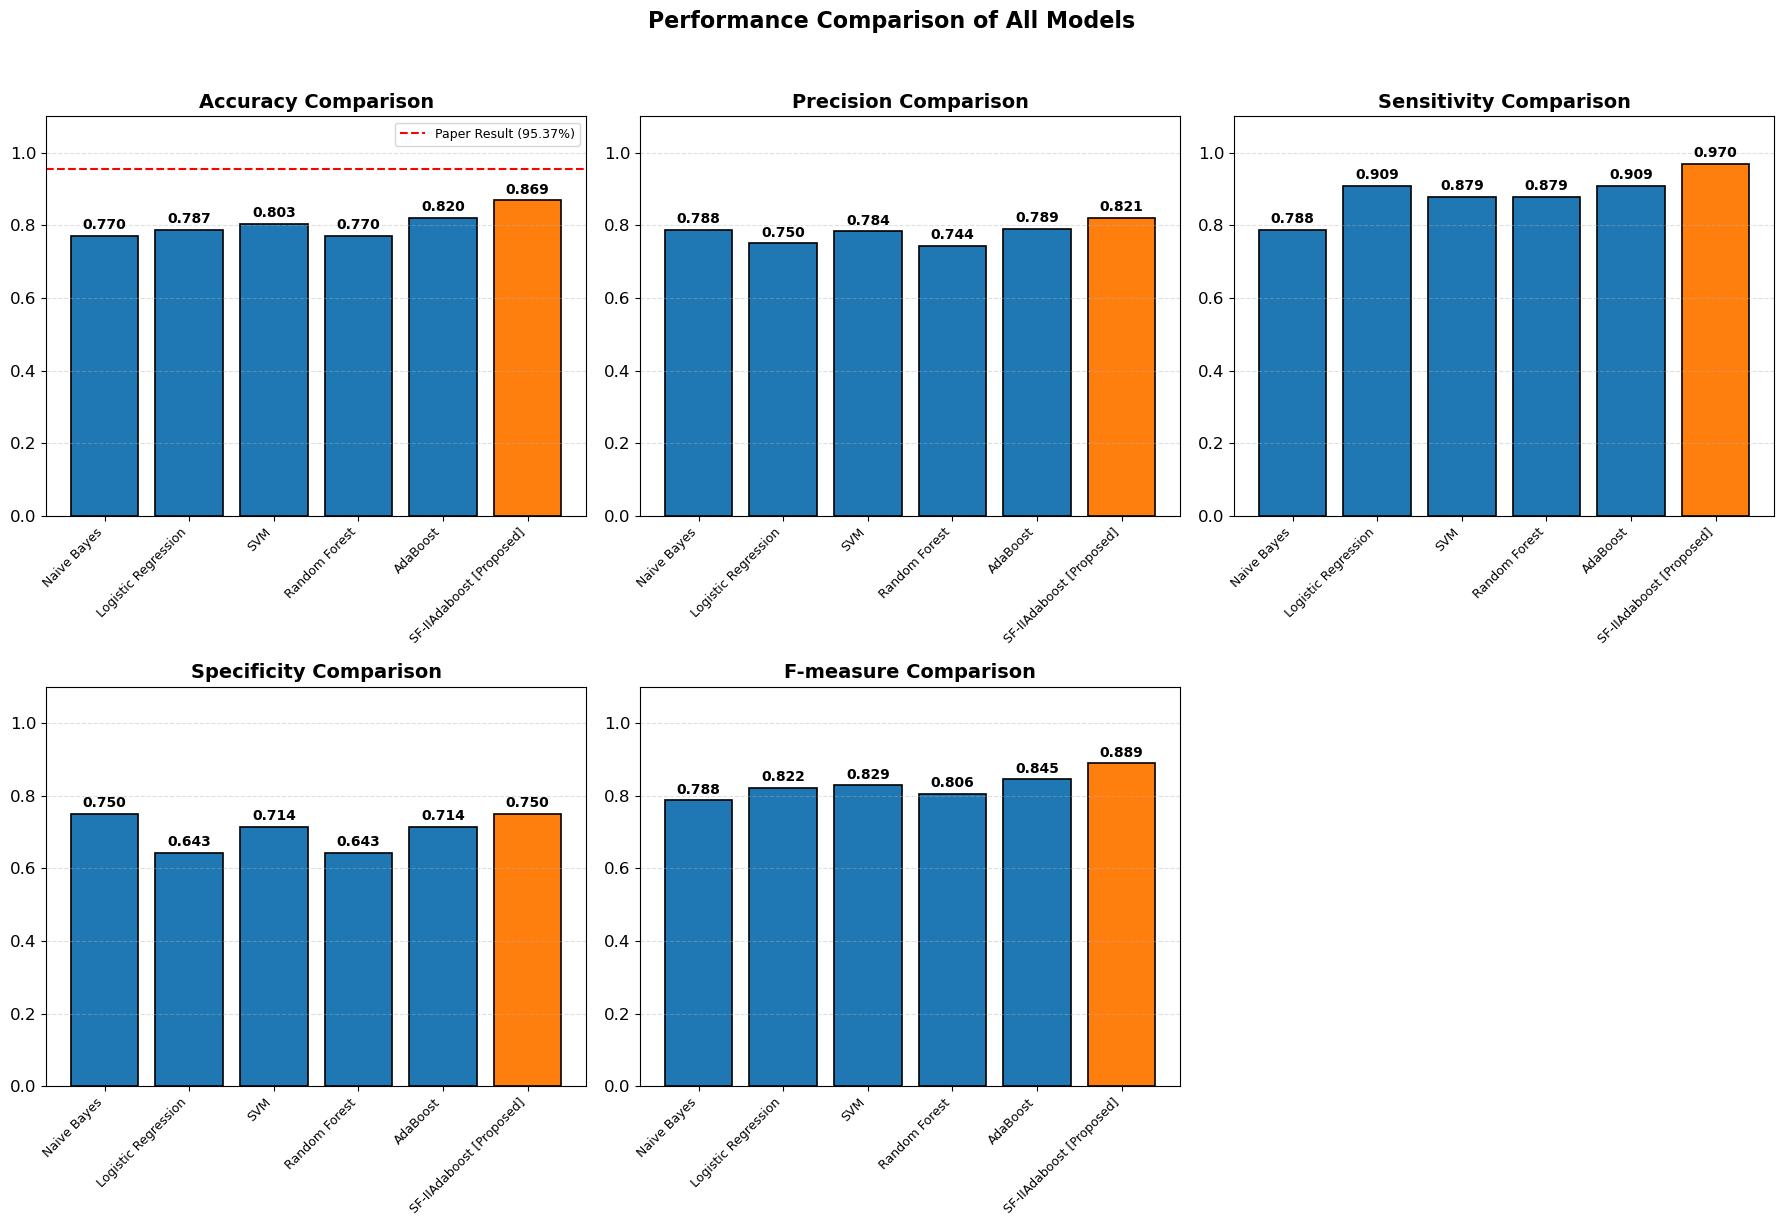

In [25]:
# تنظیمات ظاهری نمودارها
plt.rcParams['font.size'] = 12
metrics_list = ['Accuracy', 'Precision', 'Sensitivity', 'Specificity', 'F-measure']
models_names = results_df.index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics_list):
    ax = axes[i]
    values = results_df[metric].values
    
    bar_colors = ['#ff7f0e' if name == 'SF-IIAdaboost [Proposed]' else '#1f77b4' for name in models_names]
    
    x_pos = range(len(models_names))
    bars = ax.bar(x_pos, values, color=bar_colors, edgecolor='black', linewidth=1.2)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models_names, rotation=45, ha='right', fontsize=9)
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    if metric == 'Accuracy':
        ax.axhline(y=0.9537, color='red', linestyle='--', linewidth=1.5, label='Paper Result (95.37%)')
        ax.legend(fontsize=9)

axes[5].set_visible(False)

plt.suptitle('Performance Comparison of All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison_all.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
import sys
print(sys.executable)

c:\Users\Farzad\Desktop\final_project\amali\code\venv\Scripts\python.exe
